In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

In [34]:
load_dotenv()

True

In [35]:
class BlogCreator(TypedDict):
    content: str
    outline: str
    blogtext: str

In [36]:
model= ChatOpenAI(temperature=0.7)

In [37]:
def create_outline(state: BlogCreator) -> BlogCreator:
  cont= state["content"]
  prompt= f"Create a outline for the topic given by user {cont}. Rules: If input is not an area for the subject or having any offensive, sexual, voilence input. Reject with a phrase 'Not a valid subject!'."
  state["outline"] = model.invoke(prompt).content
  return state

In [38]:
def create_blogtext(state: BlogCreator) -> BlogCreator:
  outline= state["outline"]
  prompt= f"Create a short detailed blog on this outline: {outline}. Rules: If input is 'Not a valid subject!' return the same."
  state["blogtext"] = model.invoke(prompt).content
  return state

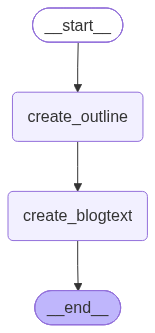

In [ ]:
#Call graph1
graph= StateGraph(BlogCreator)

#Add Node
graph.add_node('create_outline',create_outline)
graph.add_node('create_blogtext',create_blogtext)

#Add Edge
graph.add_edge(START,'create_outline')
graph.add_edge('create_outline','create_blogtext')
graph.add_edge('create_blogtext',END)

workflow= graph.compile()
workflow

In [40]:
user_input={"content": "Server"}
workflow.invoke(user_input)

{'content': 'Server',
 'outline': 'Outline for the topic "Server":\n\nI. Introduction\n    A. Definition of a server\n    B. Importance of servers in technology\n\nII. Types of Servers\n    A. Web servers\n    B. File servers\n    C. Email servers\n    D. Database servers\n\nIII. Functions of Servers\n    A. Storing and managing data\n    B. Hosting websites and applications\n    C. Facilitating communication\n    D. Providing security\n\nIV. Server Hardware\n    A. Processors\n    B. Memory\n    C. Storage devices\n    D. Network interfaces\n\nV. Server Software\n    A. Operating systems\n    B. Server applications\n    C. Virtualization software\n    D. Security software\n\nVI. Server Maintenance\n    A. Regular updates\n    B. Backup and recovery procedures\n    C. Monitoring performance\n    D. Security protocols\n\nVII. Future Trends in Server Technology\n    A. Cloud computing\n    B. Edge computing\n    C. Artificial intelligence integration\n    D. Green computing initiatives\n